In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
drive.mount('/content/drive')
titanic = pd.read_csv('/content/drive/MyDrive/dane/titanic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Podzieliłem moją pracę na etapy, żeby trzymać się ścisłego planu i hopefully poprawnie wykonać zadanie z uwzględnieniem wniosków z poprzedniego zadania i nie doprowadzić do wycieku danych:
1. zamiana surowych kolumn na inne, lepsze
2. podział na train i test
3. czyszczenie brakow, kodowanie, skalowanie
4. utworzenie modelu dummy classifier (baseline) i trening na secie treningowym
5. utworzenie wlasciwego modelu np knn, tree, svm i wyodrebnienie najlepszych hiperparametrow za pomoca gridsearch
6. najlepszy model robi predict test
7. wnioski



Zgodnie z wnioskami z poprzedniego zadania, przeprowadzam zmiany na poszczególnych kolumnach: ```Cabin``` na ```Has_cabin``` ponieważ braki stanowią aż ok 80% kolumny więc dzielimy to na ma kabinę i nie ma / nie wiadomo, porzucamy niepotrzebne kolumny które nie dają mi za dużo informacji przydatnych do trenowania modelu, oraz liczymy członków rodziny żeby jeszcze bardziej zredukować liczbe kolumn.

In [2]:
#1
titanic['Has_Cabin'] = titanic['Cabin'].notna().astype(int)
titanic = titanic.drop(columns=['Cabin'])

titanic = titanic.drop(columns=['Ticket', 'Name', 'PassengerId'])

titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic = titanic.drop(columns=['SibSp', 'Parch'])


In [3]:
#2 dzielimy wzgledem survived
X_train, X_test, y_train, y_test = train_test_split(titanic.drop(columns=['Survived']), titanic['Survived'], test_size=0.2, random_state=2137, stratify=titanic['Survived'])

In [4]:
#3
# uzupelnianie brakow rowniez wedlug wytycznych z poprzedniego zadania
# embarked modą
mode_embarked = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(mode_embarked)
X_test['Embarked']  = X_test['Embarked'].fillna(mode_embarked)

# fare medianą względem klasy
fare_medians = X_train.groupby('Pclass')['Fare'].median().to_dict()
X_train['Fare'] = X_train['Fare'].fillna(X_train['Pclass'].map(fare_medians))
X_test['Fare']  = X_test['Fare'].fillna(X_test['Pclass'].map(fare_medians))

# age z rozkładu
np.random.seed(67)
train_ages = X_train['Age'].dropna().values
X_train['Age'] = X_train['Age'].apply(lambda x: np.random.choice(train_ages) if pd.isna(x) else x)
X_test['Age']  = X_test['Age'].apply(lambda x: np.random.choice(train_ages) if pd.isna(x) else x)

# kodowanie kategorycznych
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoded_train = pd.DataFrame(encoder.fit_transform(X_train[['Embarked']]), columns=encoder.get_feature_names_out(['Embarked']),index=X_train.index)
encoded_test = pd.DataFrame(encoder.transform(X_test[['Embarked']]), columns=encoder.get_feature_names_out(['Embarked']), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=['Embarked']), encoded_train], axis=1)
X_test  = pd.concat([X_test.drop(columns=['Embarked']), encoded_test], axis=1)

sex = {'female': 0, 'male': 1}
X_train['Sex'] = X_train['Sex'].map(sex)
X_test['Sex']  = X_test['Sex'].map(sex)

# skalowanie numerycznych
standard = StandardScaler()
robust = RobustScaler()
X_train[['Fare', 'FamilySize']] = robust.fit_transform(X_train[['Fare', 'FamilySize']])
X_test[['Fare', 'FamilySize']]  = robust.transform(X_test[['Fare', 'FamilySize']])
X_train[['Age']] = standard.fit_transform(X_train[['Age']])
X_test[['Age']]  = standard.transform(X_test[['Age']])


In [5]:
#4
model = DummyClassifier(strategy='uniform')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.63      0.56      0.60       110
           1       0.41      0.48      0.44        69

    accuracy                           0.53       179
   macro avg       0.52      0.52      0.52       179
weighted avg       0.55      0.53      0.54       179



array([[62, 48],
       [36, 33]])

Średnio 52% accuracy, co stanowi niską poprzeczkę dla naszego modelu. Przejdźmy teraz do wyboru tego najlepszego.

POTĘŻNY test modeli

In [6]:
#5
models = [
    {
        'name': 'DecisionTree',
        'model': DecisionTreeClassifier(random_state=2137),
        'params': {
            'max_depth':         [2, 3, 5, 10, None],
            'criterion':         ['gini', 'entropy'],
            'min_samples_leaf':  [1, 3, 5],
        }
    },
    {
        'name': 'k-NN',
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 11],
            'weights': ['uniform', 'distance']
        }
    },
    {
        'name': 'SVM',
        'model': SVC(random_state=2137),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    }
]
results = []
for model in models:
    grid = GridSearchCV(model['model'], model['params'], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    results.append({
        'model': model['name'],
        'najlepszy wynik': grid.best_score_,
        'najlepsze hiperparametry': grid.best_params_,
        'najlepszy model': grid.best_estimator_
})
# niech sie dzieje magia
results_df = pd.DataFrame(results).sort_values(by='najlepszy wynik', ascending=False)
display(results_df)

,model,najlepszy wynik,najlepsze hiperparametry,najlepszy model
0,DecisionTree,0.811799,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...","DecisionTreeClassifier(max_depth=10, min_sampl..."
2,SVM,0.809012,"{'C': 10, 'kernel': 'rbf'}","SVC(C=10, random_state=2137)"
1,k-NN,0.804826,"{'n_neighbors': 11, 'weights': 'uniform'}",KNeighborsClassifier(n_neighbors=11)


Walka na żyletki ale ostatecznie DecisionTree pokonuje SVM o długość nosa, zatem to on zostanie naszym modelem który podejmie się ostatecznego testu. Same wyniki prezentują się pozytywnie i znacznie przewyższają wyniki baseline. Zanim jednak przejdę do testowania zwycięzcy zwizualizuję zależność accuracy od hiperparametrów reszty uczestników.

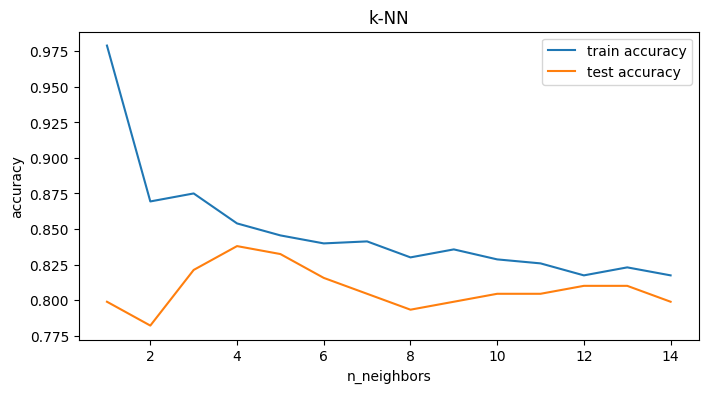

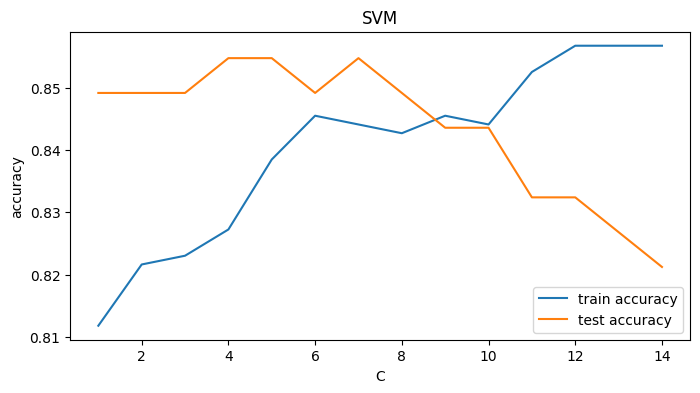

In [7]:
neighbors = range(1, 15)
train_acc, test_acc = [], []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform').fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.title('k-NN')
plt.plot(neighbors, train_acc, label='train accuracy')
plt.plot(neighbors, test_acc, label='test accuracy')
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.legend()
plt.show()

c_val = range(1,15)
train_acc, test_acc = [], []

for c in c_val:
    svm = SVC(C=c, kernel='rbf', random_state=2137).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, svm.predict(X_train)))
    test_acc.append(accuracy_score(y_test, svm.predict(X_test)))
plt.figure(figsize=(8, 4))
plt.title('SVM')
plt.plot(c_val, train_acc, label='train accuracy')
plt.plot(c_val, test_acc, label='test accuracy')
plt.xlabel('C')
plt.ylabel('accuracy')
plt.legend()
plt.show()


Na wykresach widać idealnie, że wysoki wynik podczas treningu ma się nijak do wyników na teście. k-NN: Ogromny spadek accuracy na treningu przy przejściu z jednego sąsiada na dwóch i dalszy spadek, ale podczas testu widać wzrost i dopiero potem spadek(ciekawe czy ten nagły wzrost przy 4 sąsiadach był wynikiem szczęścia czy doszło do jakiegoś wycieku). Z SVM z kolei sytuacja odwrotna, train accuracy rośnie, a test accuracy w tym samym czasie zalicza spadek. Niemniej jednak rozstrzał jest dosyć mały bo ok. 4% między maxem a minimum, w przeciwieństwie do k-NN gdzie ten rozstrzał na wykresie wynosi aż 20%, słaba stabilność modelu. Oczywiście miejmy z tyłu głowy, że powyższe wykresy treningowe nie są wynikiem kroswalidacji a pojedynczych treningów, ale chciałem je uwzględnić dla zobrazowania jak zmieniają się wyniki w zależności od jednego hiperparametru. Przejdźmy zatem do testu finałowego naszego zwycięzcy.

In [8]:
#6
winner = results_df.iloc[0]['najlepszy model']

y_pred_test = winner.predict(X_test)
y_pred_train = winner.predict(X_train)

print(classification_report(y_train, y_pred_train))
confusion_matrix(y_train, y_pred_train)
print(classification_report(y_test, y_pred_test))
confusion_matrix(y_test, y_pred_test)

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       439
           1       0.87      0.79      0.83       273

    accuracy                           0.88       712
   macro avg       0.88      0.86      0.87       712
weighted avg       0.88      0.88      0.88       712

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       110
           1       0.83      0.72      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179



array([[100,  10],
       [ 19,  50]])

#7
Jak widzimy naszemu modelowi udało się uzyskać 84% na secie testowym, jest to nieznacznie wyżej niż na gridsearch więc raczej nie doszło tutaj do przeuczenia. Naprawdę wysoki recall osób zmarłych, nie można tego samego powiedzieć o osobach, które przeżyły, gdzie ten wskaźnik jest duużo niższy. Model po prostu przeocza ludzi którzy mogli przeżyć. Wynika to najprawdopodobniej z faktu, że osób zmarłych było o wiele więcej niż ocalałych. Overall myślę, że poszło mu naprawdę dobrze, chociaż teraz wiedząc już jak się rozjeżdża recall, być może lepszą metryką niż accuracy w gridsearch byłby właśnie recall. Sprawdźmy teraz wyniki modelu gdy pozmieniamy trochę hiperparametry.

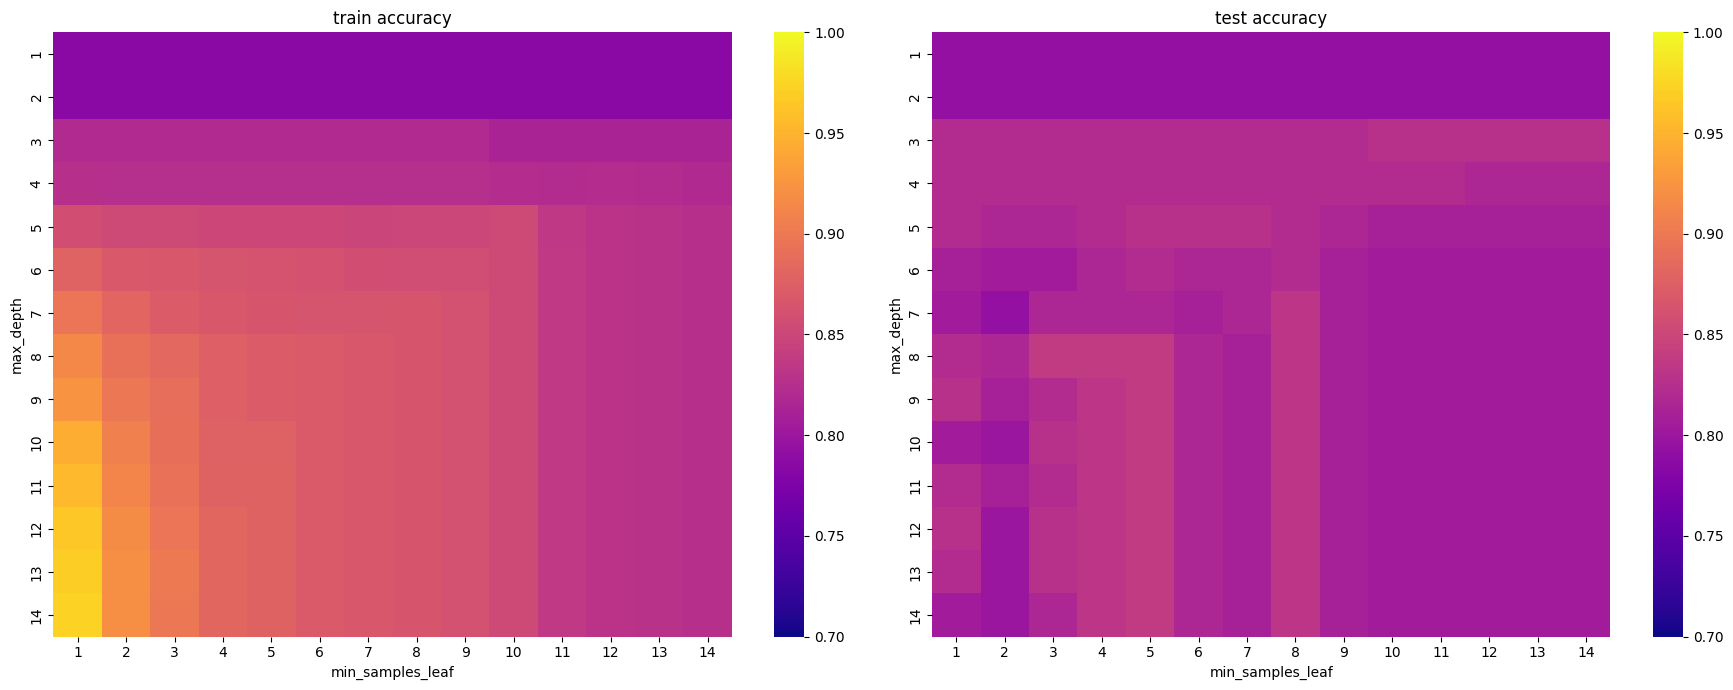

In [9]:
leafs = range(1, 15)
depths = range(1, 15)
train_scores = []
test_scores = []

results=[]
for d in depths:
    for l in leafs:
        model = DecisionTreeClassifier(max_depth=d, min_samples_leaf=l, random_state=2137)
        model.fit(X_train, y_train)
        results.append({
            'max_depth': d,
            'min_samples_leaf': l,
            'train_acc': accuracy_score(y_train, model.predict(X_train)),
            'test_acc': accuracy_score(y_test, model.predict(X_test))
        })
df_res = pd.DataFrame(results)
pivot_train = df_res.pivot(index='max_depth', columns='min_samples_leaf', values='train_acc')
pivot_test = df_res.pivot(index='max_depth', columns='min_samples_leaf', values='test_acc')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pivot_train, ax=axes[0], cmap='plasma', vmin=0.7, vmax=1.0)
axes[0].set_title('train accuracy', fontsize=12)
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(pivot_test, ax=axes[1], cmap='plasma', vmin=0.7, vmax=1.0)
axes[1].set_title('test accuracy', fontsize=12)
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')
plt.tight_layout()
plt.show()



Heatmapa train accuracy ładnie nam obrazuje, że model ulega przeuczeniu i po prostu uczy się na pamięć rozwiązań i uzyskuje niemalże 100% accuracy dla skrajnych hiperparametrów. Natomiast test accuracy pozwala nam wyodrębnić jaskrawe punkty, z których możemy wyciągnąć te hiperparametry, dla których accuracy było najlepsze, np. widzimy, że dla ```min_samples_leaf=8``` i ```max_depth od 7 do 14``` accuracy jest zauważalnie wyższe niż dla sąsiednich kolumn. Widać również zwycięski wynik z gridsearch czyli ```max_depth=10``` oraz ```min_samples_leaf=5```